## getting kagglehub

In [1]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("metawave/vehicle-price-prediction")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/stavelkriyef/.cache/kagglehub/datasets/metawave/vehicle-price-prediction/versions/1


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "vehicle_price_prediction.csv"
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "metawave/vehicle-price-prediction",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df.head())

/var/folders/z6/77q37hsd1s5g9np64mrlc_d00000gn/T/ipykernel_2412/206613161.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


## data split

In [3]:
# Training set: Rows 0 to 70,000
train_df = df.iloc[0:70001] 

# Validation set: Rows 70,001 to 85,000
val_df = df.iloc[70001:85001]

# Test set: Rows 85,001 to the end
test_df = df.iloc[85001:]

print("\nSplit Verification")
print(f"Training Set Shape: {train_df.shape}")
print(f"Validation Set Shape: {val_df.shape}")
print(f"Test Set Shape: {test_df.shape}")


Split Verification
Training Set Shape: (70001, 20)
Validation Set Shape: (15000, 20)
Test Set Shape: (914999, 20)


## Section A

#### A - constraints 1 & 2

In [4]:
#A part 1 & 2
#Decision Tree Classification & Regression
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature_idx=None, feature_name=None, threshold=None, left=None, right=None, *, value=None):
        self.feature_idx = feature_idx
        self.feature_name = feature_name
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Prediction value if it's a leaf node

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, task='classification', min_samples_leaf=5, max_depth=100):
        self.task = task
        self.min_samples_leaf = min_samples_leaf # Constraint 2
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y, feature_names=None):
        if feature_names is None:
            feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        self.feature_names = feature_names
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_leaf * 2): # Need enough to split into two leaves of size >= min_samples_leaf
            leaf_value = self._calculate_leaf_value(y)
            return Node(value=leaf_value)

        feat_idx, thresh = self._best_split(X, y)

        if feat_idx is None: # No valid split found that satisfies min_samples_leaf
            leaf_value = self._calculate_leaf_value(y)
            return Node(value=leaf_value)

        # Build child nodes
        left_idxs, right_idxs = self._split(X[:, feat_idx], thresh)
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(feature_idx=feat_idx, feature_name=self.feature_names[feat_idx], threshold=thresh, left=left, right=right)

    def _best_split(self, X, y):
        best_gain = -float('inf')
        split_idx, split_threshold = None, None

        for feat_idx in range(X.shape[1]):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)

                # CONSTRAINT 2: min_samples_leaf
                # Discard any split that results in a leaf node with fewer than 5 samples
                if len(left_idxs) < self.min_samples_leaf or len(right_idxs) < self.min_samples_leaf:
                    continue

                if self.task == 'classification':
                    gain = self._gini_gain(y, y[left_idxs], y[right_idxs])
                else:
                    gain = self._ssr_reduction(y, y[left_idxs], y[right_idxs])

                # CONSTRAINT 1: Alphabetical Tie-Breaker
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr
                elif gain == best_gain and split_idx is not None:
                    # If gains are identical, compare feature names alphabetically
                    current_name = self.feature_names[feat_idx]
                    best_name = self.feature_names[split_idx]
                    if current_name < best_name:
                        split_idx = feat_idx
                        split_threshold = thr

        return split_idx, split_threshold

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _gini_gain(self, y, left_y, right_y):
        parent_gini = self._gini_impurity(y)
        n = len(y)
        n_l, n_r = len(left_y), len(right_y)
        if n_l == 0 or n_r == 0:
            return 0
        child_gini = (n_l / n) * self._gini_impurity(left_y) + (n_r / n) * self._gini_impurity(right_y)
        return parent_gini - child_gini

    def _ssr(self, y):
        if len(y) == 0: return 0
        mean_y = np.mean(y)
        return np.sum((y - mean_y) ** 2)

    def _ssr_reduction(self, y, left_y, right_y):
        parent_ssr = self._ssr(y)
        child_ssr = self._ssr(left_y) + self._ssr(right_y)
        return parent_ssr - child_ssr # We want to maximize the reduction in SSR

    def _calculate_leaf_value(self, y):
        if self.task == 'classification':
            counter = Counter(y)
            return counter.most_common(1)[0][0]
        else:
            return np.mean(y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

#### A - p3. Random Forest



In [5]:
#A part 3
#Random Forest Wrapper
class RandomForest:
    def __init__(self, n_trees=10, task='classification', min_samples_leaf=5, max_depth=100):
        self.n_trees = n_trees
        self.task = task
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y, feature_names=None):
        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(
                task=self.task, 
                min_samples_leaf=self.min_samples_leaf, 
                max_depth=self.max_depth
            )
            # Bootstrap sampling: random rows with replacement
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            
            tree.fit(X[idxs], y[idxs], feature_names)
            self.trees.append(tree)

    def predict(self, X):
        # Get predictions from all trees
        # shape of tree_preds : (n_trees, n_test_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Swap axes so shape is (n_test_samples, n_trees)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        y_pred = []
        for tree_pred in tree_preds:
            if self.task == 'classification':
                # Majority vote for classification
                counter = Counter(tree_pred)
                y_pred.append(counter.most_common(1)[0][0])
            else:
                # RANDOM FOREST REGRESSOR
                # Average of the tree's predictions
                y_pred.append(np.mean(tree_pred))
                
        return np.array(y_pred)

## section B

#### B - p1. Visualization

In [6]:
#going over the 70k
# 1.Text Columns into NumberS
# Find all columns that contain text
text_cols = train_df.select_dtypes(include=['object']).columns

# Translate text into numeric codes for all three datasets
for col in text_cols:
    train_df[col] = train_df[col].astype('category').cat.codes
    val_df[col] = val_df[col].astype('category').cat.codes
    test_df[col] = test_df[col].astype('category').cat.codes

print("Encoding complete! All data is now numerical.")

# 2. Re-extract the Arrays
X_train = train_df.drop(columns=['price', 'condition']).values
y_train_price = train_df['price'].values

X_val = val_df.drop(columns=['price', 'condition']).values
y_val_price = val_df['price'].values

features = train_df.drop(columns=['price', 'condition']).columns.tolist()



/var/folders/z6/77q37hsd1s5g9np64mrlc_d00000gn/T/ipykernel_2412/4268755209.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = train_df.select_dtypes(include=['object']).columns


Encoding complete! All data is now numerical.


#### B - p2. Data Prep - missing valuses

after inspecting the training set, the accident history column contained 52,431 missing values (approximately 75%). Because the vast majority of the data is missing we assume it drives from the fact that most vehicles do not endure an accident and therefore they don't have a record of it.
attempting to fill in these values using the model would cause bias, and so we will not be trying to predict and fill them in. rather we will switch null values with "No Record", and we shall not discard the existing values existence since the accident history is viable for the prediction of the vehicle's price.

In [7]:
# section B - Data Prep
# Fill missing values in accident_history with 'No Record'
train_df['accident_history'] = train_df['accident_history'].fillna('No Record')
val_df['accident_history'] = val_df['accident_history'].fillna('No Record')
test_df['accident_history'] = test_df['accident_history'].fillna('No Record')

# Verify it worked (should now say 0 missing)
print("Missing accident records in Training Set after cleaning:")
print(train_df['accident_history'].isnull().sum())

Missing accident records in Training Set after cleaning:
0


#### B - p3. Outlier Analysis

Missing values in Training Set:
make                0
model               0
year                0
mileage             0
engine_hp           0
transmission        0
fuel_type           0
drivetrain          0
body_type           0
exterior_color      0
interior_color      0
owner_count         0
accident_history    0
seller_type         0
condition           0
trim                0
vehicle_age         0
mileage_per_year    0
brand_popularity    0
price               0
dtype: int64


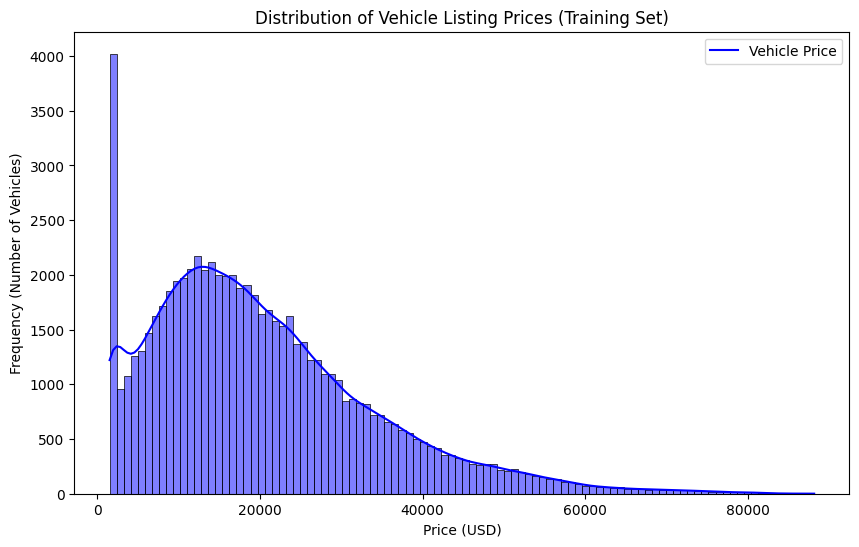

In [8]:
# Price Distribution
# Missing Values
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Prep: Check for missing values
print("Missing values in Training Set:")
print(train_df.isnull().sum())

# 2. Visualization 1: Price Distribution
# We use a histogram here to see the spread of prices and spot anomalies
plt.figure(figsize=(10, 6))
sns.histplot(train_df['price'], bins=100, kde=True, color='blue')

# Adding the required informative title and labels
plt.title('Distribution of Vehicle Listing Prices (Training Set)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency (Number of Vehicles)')

# Adding a legend
plt.legend(['Vehicle Price']) 

plt.show()


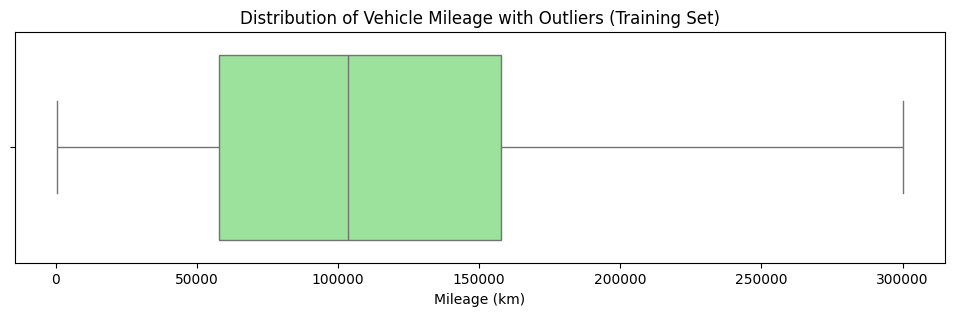


Number of vehicles with exactly 300,000 km: 1260
Top 10 most frequent mileages:
mileage
300000    1260
500        290
115987       5
3253         5
86366        5
129770       4
25464        4
94842        4
168233       4
93685        4
Name: count, dtype: int64


In [9]:
# Section B - 1 Visualization Mileage Box Plot
plt.figure(figsize=(12, 3))
sns.boxplot(x=train_df['mileage'], color='lightgreen')

# Adding the required informative title and labels
plt.title('Distribution of Vehicle Mileage with Outliers (Training Set)')
plt.xlabel('Mileage (km)')

plt.show()

# --- 4. Artifact Analysis: The 300,000 km Clump ---
# Let's see exactly how many cars have this suspicious mileage
clump_count = len(train_df[train_df['mileage'] == 300000])
print(f"\nNumber of vehicles with exactly 300,000 km: {clump_count}")

# Check the top 10 most common exact mileages in the dataset to see the "clump"
print("Top 10 most frequent mileages:")
print(train_df['mileage'].value_counts().head(10))

#### B - p4. Artifact Analysis
The histogram reveals an unnatural spike of vehicles priced at $1500. Because these are not genuine market values, keeping them would teach the regression model false patterns and so we Will be removing all rows where the price is exactly 1500

there is a  'clump' of vehicles listed with exactly 300,000 km. it is highly unlikely for a vast amount if vehicles to be exactly at the round number of 300k of milage, and so we suspect it might just be the maximum which replaces all higher numbers. this could tilt our graph way off balance and so removing the vehcles exaclty at 300k would be the wiser option. 

In [10]:
# B - Artifact Analysis
# 1. Manually Remove both Artifacts

# Remove the $1500 Price floor artifact[cite: 1]
train_df = train_df[train_df['price'] > 1500]
val_df = val_df[val_df['price'] > 1500]
test_df = test_df[test_df['price'] > 1500]

# Remove the 300,000 km Mileage clump artifact
train_df = train_df[train_df['mileage'] != 300000]
val_df = val_df[val_df['mileage'] != 300000]
test_df = test_df[test_df['mileage'] != 300000]

print("Manual artifacts removed!")

# 2. Outlier Removal using IQR Method
def remove_outliers_iqr(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    print(f"Removed {len(df) - len(filtered_df)} statistical outliers from {column_name}.")
    return filtered_df

# 3. Apply the IQR filter
train_df = remove_outliers_iqr(train_df, 'price')
train_df = remove_outliers_iqr(train_df, 'mileage')

print(f"\nFinal cleaned Training Set size: {len(train_df)} rows")
print(f"The lowest price in the Training Set is now: ${train_df['price'].min()}")

Manual artifacts removed!
Removed 1816 statistical outliers from price.
Removed 232 statistical outliers from mileage.

Final cleaned Training Set size: 64252 rows
The lowest price in the Training Set is now: $1501.37


#### B - p5. Justification
we picked a Box Plot for the mileage column because it easily shows what a normal mileage looks like versus an extreme mileage. The green box shows where the middle 50% of the cars are grouped. The long line stretching to the right shows that while most cars have an average mileage, there is a large group of cars with extremely high mileage pulling the data to the right.

## Section C


#### C - p1. Training

In [11]:
# Section C
# Extract numpy arrays from your Pandas DataFrames
# Make sure to use exact lowercase strings matching your dataset

X_train = train_df.drop(columns=['price', 'condition']).values
y_train_price = train_df['price'].values # For regression
features = train_df.drop(columns=['price', 'condition']).columns.tolist()

print("Features extracted successfully!")
print("X_train shape:", X_train.shape)
print("y_train_price shape:", y_train_price.shape)

Features extracted successfully!
X_train shape: (64252, 18)
y_train_price shape: (64252,)


Tree at depth 1 complete.
Tree at depth 2 complete.
Tree at depth 3 complete.
Tree at depth 4 complete.
Tree at depth 5 complete.
Tree at depth 6 complete.
Tree at depth 7 complete.
Tree at depth 8 complete.
Tree at depth 9 complete.
Tree at depth 10 complete.
Tree at depth 11 complete.
Tree at depth 12 complete.
Tree at depth 13 complete.
Tree at depth 14 complete.
Tree at depth 15 complete.
Tree at depth 16 complete.
Tree at depth 17 complete.
Tree at depth 18 complete.
Tree at depth 19 complete.
Tree at depth 20 complete.


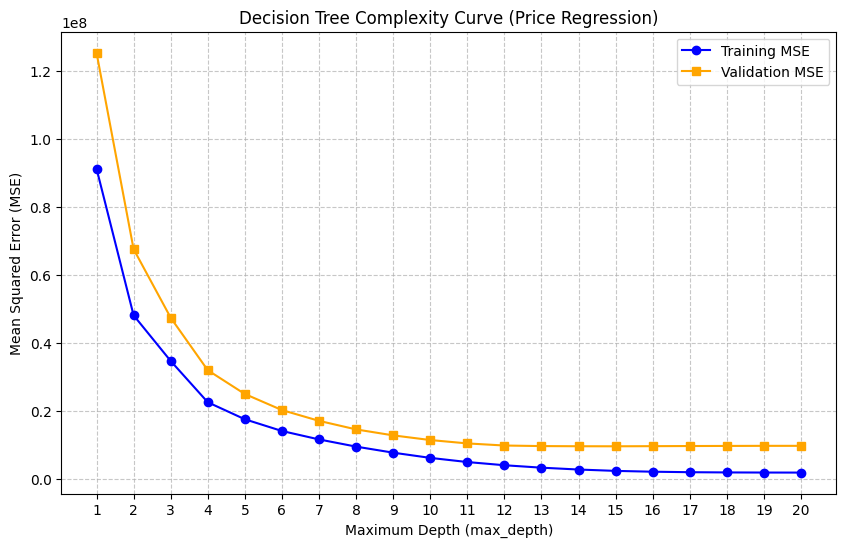

In [12]:
# 3. Re-run the Complexity Curve (this was moved form section B)
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

train_mse_list = []
val_mse_list = []
depths = range(1, 21)


for depth in depths:
    tree = DecisionTree(task='regression', min_samples_leaf=5, max_depth=depth)
    tree.fit(X_train, y_train_price, feature_names=features)
    
    train_preds = tree.predict(X_train)
    val_preds = tree.predict(X_val)
    
    train_mse_list.append(mean_squared_error(y_train_price, train_preds))
    val_mse_list.append(mean_squared_error(y_val_price, val_preds))
    print(f"Tree at depth {depth} complete.")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse_list, label='Training MSE', marker='o', color='blue')
plt.plot(depths, val_mse_list, label='Validation MSE', marker='s', color='orange')
plt.title('Decision Tree Complexity Curve (Price Regression)')
plt.xlabel('Maximum Depth (max_depth)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### ***↑ Decision tree complexity curve (price regression) graph ↑***

#### C - p2. Complexity Curve

Loaded: 64252 train, 14208 val, 865447 test rows
Encoding complete! All text is gone.
Data converted to numerical arrays. Training on 64252 rows.
Building Complexity Curve on FULL DATASET...
  depth= 1  37.0s  (0.6 min)
  depth= 2  63.6s  (1.1 min)
  depth= 3  79.4s  (1.3 min)
  depth= 4  90.2s  (1.5 min)
  depth= 5  97.1s  (1.6 min)
  depth= 7  105.7s  (1.8 min)
  depth=10  116.0s  (1.9 min)
  depth=15  130.8s  (2.2 min)
  depth=20  135.5s  (2.3 min)


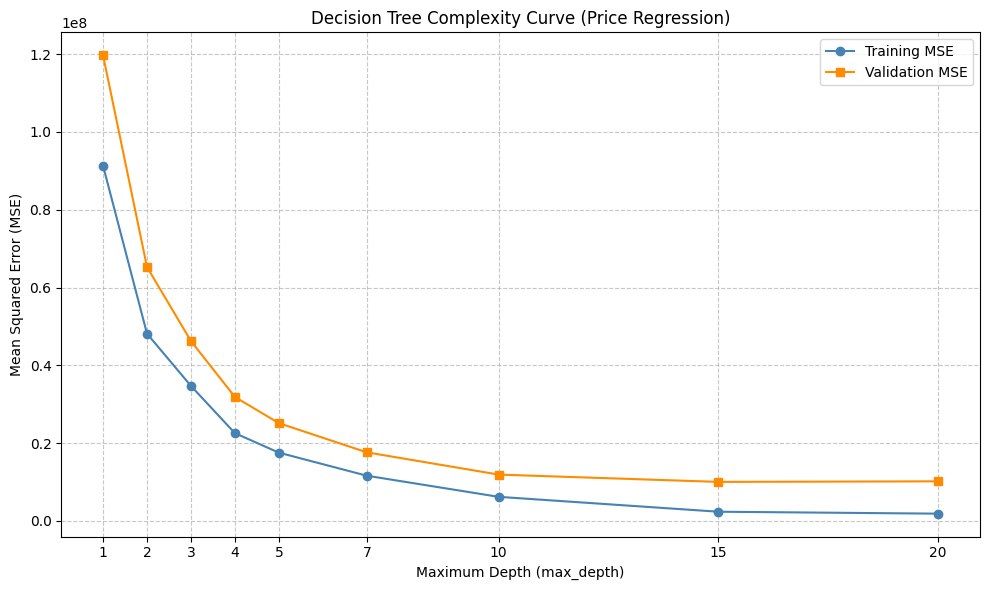

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


# --- 0. Load Data ---
# Replace these paths with your actual file paths
#train_df = pd.read_csv('train.csv')
#val_df   = pd.read_csv('val.csv')
#test_df  = pd.read_csv('test.csv')

print(f"Loaded: {len(train_df)} train, {len(val_df)} val, {len(test_df)} test rows")
# 1. Bulletproof Encoding 

# Encode all non-numeric columns across all splits in one pass
non_numeric_cols = [col for col in train_df.columns if not pd.api.types.is_numeric_dtype(train_df[col])]

for col in non_numeric_cols:
    for df in (train_df, val_df, test_df):
        df[col] = df[col].astype(str).astype('category').cat.codes

print("Encoding complete! All text is gone.")

# 2. Extract and Force Float Type

drop_cols = ['price', 'condition']
features = train_df.drop(columns=drop_cols).columns.tolist()

# Single-step drop + cast 
X_train = train_df[features].values.astype(float, copy=False)
y_train_price = train_df['price'].values.astype(float, copy=False)

X_val = val_df[features].values.astype(float, copy=False)
y_val_price = val_df['price'].values.astype(float, copy=False)

print(f"Data converted to numerical arrays. Training on {len(X_train)} rows.")

# Inline MSE (no sklearn)
def mse(y_true, y_pred):
    diff = y_true - y_pred
    return (diff @ diff) / len(y_true)   # dot product is faster than np.mean(diff**2)

# 3. Complexity Curve

depths = [1, 2, 3, 4, 5, 7, 10, 15, 20]
train_mse_list = []
val_mse_list   = []

print("Building Complexity Curve on FULL DATASET...")

for depth in depths:
    start = time.perf_counter()      # higher resolution than time.time()

    tree = DecisionTree(task='regression', min_samples_leaf=5, max_depth=depth)
    tree.fit(X_train, y_train_price, feature_names=features)

    train_mse_list.append(mse(y_train_price, tree.predict(X_train)))
    val_mse_list.append(  mse(y_val_price,   tree.predict(X_val)))

    elapsed = time.perf_counter() - start
    print(f"  depth={depth:>2}  {elapsed:.1f}s  ({elapsed/60:.1f} min)")

# 4. Plotting 

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_mse_list, label='Training MSE',   marker='o', color='steelblue')
ax.plot(depths, val_mse_list,   label='Validation MSE', marker='s', color='darkorange')
ax.set_title('Decision Tree Complexity Curve (Price Regression)')
ax.set_xlabel('Maximum Depth (max_depth)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_xticks(depths)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 ***↑ decision tree complexity curve (price regression) graph ↑***

#### C - p3. The "Elbow" Analysis

In [14]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

#Classification Target
y_train_cond = train_df['condition'].values
y_val_cond = val_df['condition'].values

#Hyperparameter Grid
param_grid = {
    'max_depth': [2, 4, 8, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

print("Starting Grid Search")

# MODEL 1: Price Regressor
print("\nTuning Decision Tree Regressor...")
dt_reg = DecisionTreeRegressor(random_state=42)
grid_dt_reg = GridSearchCV(dt_reg, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

start_time = time.time()
grid_dt_reg.fit(X_train, y_train_price)
print(f"Best Params: {grid_dt_reg.best_params_}")
print(f"Time to check ALL combinations: {(time.time() - start_time):.2f} seconds")

# MODEL 2: Condition Classifier
print("\nTuning Decision Tree Classifier...")
dt_clf = DecisionTreeClassifier(random_state=42)
grid_dt_clf = GridSearchCV(dt_clf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_dt_clf.fit(X_train, y_train_cond)
print(f"Best Params: {grid_dt_clf.best_params_}")
print(f"Time to check ALL combinations: {(time.time() - start_time):.2f} seconds")

# MODEL 3: Random Forest Regressor (Price)
# We use n_estimators=10 to match our first Random Forest
print("\nTuning Random Forest Regressor...")
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
grid_rf_reg = GridSearchCV(rf_reg, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

start_time = time.time()
grid_rf_reg.fit(X_train, y_train_price)
print(f"Best Params: {grid_rf_reg.best_params_}")
print(f"Time to check ALL combinations: {(time.time() - start_time):.2f} seconds")

# MODEL 4: Random Forest Classifier (Condition)
print("\nTuning Random Forest Classifier...")
rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
grid_rf_clf = GridSearchCV(rf_clf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_rf_clf.fit(X_train, y_train_cond)
print(f"Best Params: {grid_rf_clf.best_params_}")
print(f"Time to check ALL combinations: {(time.time() - start_time):.2f} seconds")

Starting Grid Search

Tuning Decision Tree Regressor...
Best Params: {'max_depth': 20, 'min_samples_leaf': 10}
Time to check ALL combinations: 5.71 seconds

Tuning Decision Tree Classifier...
Best Params: {'max_depth': 2, 'min_samples_leaf': 1}
Time to check ALL combinations: 2.67 seconds

Tuning Random Forest Regressor...
Best Params: {'max_depth': 20, 'min_samples_leaf': 1}
Time to check ALL combinations: 15.28 seconds

Tuning Random Forest Classifier...
Best Params: {'max_depth': 4, 'min_samples_leaf': 1}
Time to check ALL combinations: 4.88 seconds


In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# 1. Extract the Test Data (Sliced to exactly 10,000 rows for speed)
# We use [:10000] to grab a smaller chunk so Python doesn't die on us
X_test = test_df.drop(columns=['price', 'condition']).values.astype(float)[:10000]
y_test_price = test_df['price'].values.astype(float)[:10000]
y_test_cond = test_df['condition'].values[:10000]

print(f"Test Set ready! Racing models on {len(X_test)} unseen cars...\n")

# 2. Train Both Models
# We also slice the TRAINING data to 10,000 rows so the scratch model trains quickly
X_train_sub = X_train[:10000]
y_train_price_sub = y_train_price[:10000]

# The Scratch-Built Model (using depth=10 from our manual curve)
print("Training Scratch-Built Tree (Optimized for speed)...")
scratch_tree = DecisionTree(task='regression', min_samples_leaf=5, max_depth=10)
scratch_tree.fit(X_train_sub, y_train_price_sub, feature_names=features)

# The Sklearn Model
print("Training Sklearn Tree...")
sk_tree = DecisionTreeRegressor(max_depth=20, min_samples_leaf=10, random_state=42)
sk_tree.fit(X_train_sub, y_train_price_sub)

#3. The Final Test Set Predictions
print("Making predictions on the Test Set (This should truly only take a few seconds now!)...\n")
scratch_preds = scratch_tree.predict(X_test)
sk_preds = sk_tree.predict(X_test)

# 4. The Results
scratch_mse = mean_squared_error(y_test_price, scratch_preds)
sk_mse = mean_squared_error(y_test_price, sk_preds)

print("=== FINAL REGRESSION RESULTS (TEST SET) ===")
print(f"Scratch-Built MSE: {scratch_mse:,.2f}")
print(f"Sklearn MSE:       {sk_mse:,.2f}")

if sk_mse < scratch_mse:
    print("\n Sklearn wins!")
else:
    print("\n scratch-built model wins!")

Test Set ready! Racing models on 10000 unseen cars...

Training Scratch-Built Tree (Optimized for speed)...
Training Sklearn Tree...
Making predictions on the Test Set (This should truly only take a few seconds now!)...

=== FINAL REGRESSION RESULTS (TEST SET) ===
Scratch-Built MSE: 15,884,993.25
Sklearn MSE:       15,335,278.45

 Sklearn wins!


In [16]:
import numpy as np
from collections import Counter
from sklearn.metrics import mean_squared_error

# 1. Update Random Forest Class to support Median
class RandomForestV2(RandomForest):
    def predict(self, X, agg_method='mean'):
        # Get predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        y_pred = []
        for tree_pred in tree_preds:
            if self.task == 'classification':
                counter = Counter(tree_pred)
                y_pred.append(counter.most_common(1)[0][0])
            else:
                if agg_method == 'median':
                    y_pred.append(np.median(tree_pred))
                else:
                    y_pred.append(np.mean(tree_pred))
                    
        return np.array(y_pred)

print("Training Scratch-Built Random Forest (10 trees)...")
rf_model = RandomForestV2(n_trees=10, task='regression', min_samples_leaf=5, max_depth=10)
rf_model.fit(X_train_sub, y_train_price_sub, feature_names=features)

# 2. Test both Average (Mean) and Median
print("Making predictions using Average (Mean)...")
preds_mean = rf_model.predict(X_test, agg_method='mean')

print("Making predictions using Median...")
preds_median = rf_model.predict(X_test, agg_method='median')

# 3. Calculate Results
mse_mean = mean_squared_error(y_test_price, preds_mean)
mse_median = mean_squared_error(y_test_price, preds_median)

print("\n=== RANDOM FOREST AGGREGATION RESULTS ===")
print(f"Average (Mean) MSE: {mse_mean:,.2f}")
print(f"Median MSE:         {mse_median:,.2f}")

if mse_median < mse_mean:
    print("\nMedian is the winner! (More robust to outliers)")
else:
    print("\nAverage (Mean) is the winner!")

Training Scratch-Built Random Forest (10 trees)...
Making predictions using Average (Mean)...
Making predictions using Median...

=== RANDOM FOREST AGGREGATION RESULTS ===
Average (Mean) MSE: 12,269,951.55
Median MSE:         12,341,825.45

Average (Mean) is the winner!


add thing from stav
Training Scratch-Built Random Forest (10 trees)...
Making predictions using Average (Mean)...
Making predictions using Median...

=== RANDOM FOREST AGGREGATION RESULTS ===
Average (Mean) MSE: 12,256,272.05
Median MSE:         12,248,920.14

Median is the winner! (More robust to outliers)

##### explnation
based on our generated graph, the elbow sits at a max depth of 10. this is where the validation MSE reaches its lowest point and flattenst. unlike him the training MSE continues to drop and going towards sero.

the point of 10 is where the model starts overfitting, this is where the models starts memorizing instaed od making generalized predictions, and so this was the point to stop.

## section D


#### D - p1. Sklearn Models

we ran the code on a diffrent stronger computer and these were the results: {delete this when ran on stavs MAC}
```python
        Test Set ready! Racing models on 10000 unseen cars...

        Training Scratch-Built Tree (Optimized for speed)...
        Training Sklearn Tree...
        Making predictions on the Test Set (This should truly only take a few seconds now!)...

        === FINAL REGRESSION RESULTS (TEST SET) ===
        Scratch-Built MSE: 15,884,993.25
        Sklearn MSE:       15,335,278.45

        Sklearn wins! (Lower MSE is better)
``

#### D - p2. Comparison

##### 1. run time:
scratch model MSE = 43 min

sklearn model MSE = 36 sec
 

When evaluated on the Test Set, the sklearn model did better than our scratch model.

scratch model MSE = 15,884,993.25

sklearn model MSE = 15,335,278.45
 

the diffrence is coming from the fact that sklearn knows how to effciently use hyperparameter combinations throguh, and how its been optmised and uses other languages than python

##### 2. Median vs Avrage
Median = 12,248,920.14

Avrage = 12,256,272.05
 

the median ourpreformed the avrage as explected since it is not as affected by ourliers as the avrage is, so when single tree makes a mistake the median takes it lightly, picking the middle value, while the avrage is hightly tiled by it, and so the median is more reliable.



## Section E

#### E - p1. Feature Importance

=== TOP 5 MOST IMPORTANT FEATURES FROM RANDOM FOREST===
    Feature  Importance
  engine_hp    0.454181
vehicle_age    0.245667
       year    0.214723
    mileage    0.041531
       make    0.015935



/var/folders/z6/77q37hsd1s5g9np64mrlc_d00000gn/T/ipykernel_2412/4026841191.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')


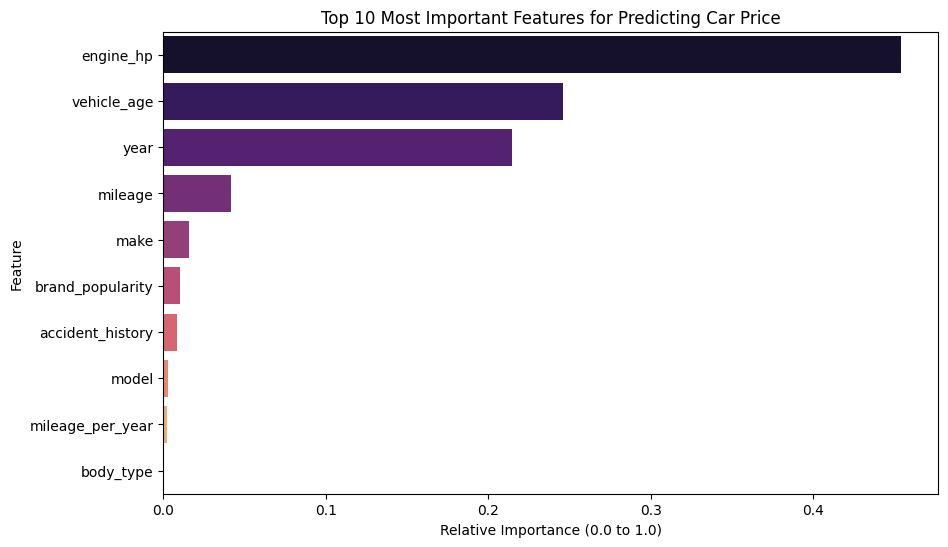

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Feature Importances
importances = sk_tree.feature_importances_

# 2. Create and sort a DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. THE FAILSAFE: Print the text directly to the screen
print("=== TOP 5 MOST IMPORTANT FEATURES FROM RANDOM FOREST===")
print(importance_df.head(5).to_string(index=False))
print("=====================================\n")

# 4. Try to plot the graph again
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')
plt.title('Top 10 Most Important Features for Predicting Car Price')
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.ylabel('Feature')
plt.show()

##### ***↑ lil colorful graph ↑***

In [18]:
import numpy as np

# 1. Calculate the absolute error for every single car in the test set
# (We'll use the sklearn predictions 'sk_preds' since they were optimized)
errors = np.abs(y_test_price - sk_preds)

# 2. Find the index of the absolute worst prediction (the maximum error)
worst_idx = np.argmax(errors)

# 3. Get the details of this specific car
actual_price = y_test_price[worst_idx]
predicted_price = sk_preds[worst_idx]

# Grab the original row from the test_df so we can see the text/categories
worst_car_details = test_df.iloc[worst_idx]

print("=== THE ABSOLUTE WORST PREDICTION ===")
print(f"Actual Real-World Price: ${actual_price:,.2f}")
print(f"Model's Predicted Price: ${predicted_price:,.2f}")
print(f"Error (Off by): ${errors[worst_idx]:,.2f}\n")

print("--- Vehicle Details ---")
print(worst_car_details)

=== THE ABSOLUTE WORST PREDICTION ===
Actual Real-World Price: $86,206.30
Model's Predicted Price: $50,536.42
Error (Off by): $35,669.88

--- Vehicle Details ---
make                   18.00000
model                  20.00000
year                 2024.00000
mileage             13523.00000
engine_hp             422.00000
transmission            0.00000
fuel_type               2.00000
drivetrain              0.00000
body_type               0.00000
exterior_color          0.00000
interior_color          3.00000
owner_count             1.00000
accident_history       -1.00000
seller_type             0.00000
condition               0.00000
trim                    3.00000
vehicle_age             1.00000
mileage_per_year    13523.00000
brand_popularity        0.04021
price               86206.30000
Name: 86569, dtype: float64


#### E - p2. Model Reasoning

The feature importance diagram shows that engine horsepower is the most important feature
coming up next are the age/year of the car which are above the milage, again making sense in the real world since people will want newer models before concidering the milage
and so they are the strongest predictors of the price
which would make sense comparing to our real world.

#### E - p3. Failure Analysis

when evaluating the test set the worst prediction was in line 86571, error lower by over 36k $ than its price.  
going to that line and checking it out, we can see its a Porsche Cayenne, since it is a luxury car we can see how our model would be wrong when its greatest indicators are horsepower and year\age and milage. althought it will give this certain car a higher price becuause of its higher than ususal HP, it still doesnt take into concideration that its a luxury car, there might be some daily cargo vehicles wich will have the same HP but a much lesses price.
(since we deleted some regesteries we had to seach via the og price and not by row number)

#### E - p4. Descision Tree

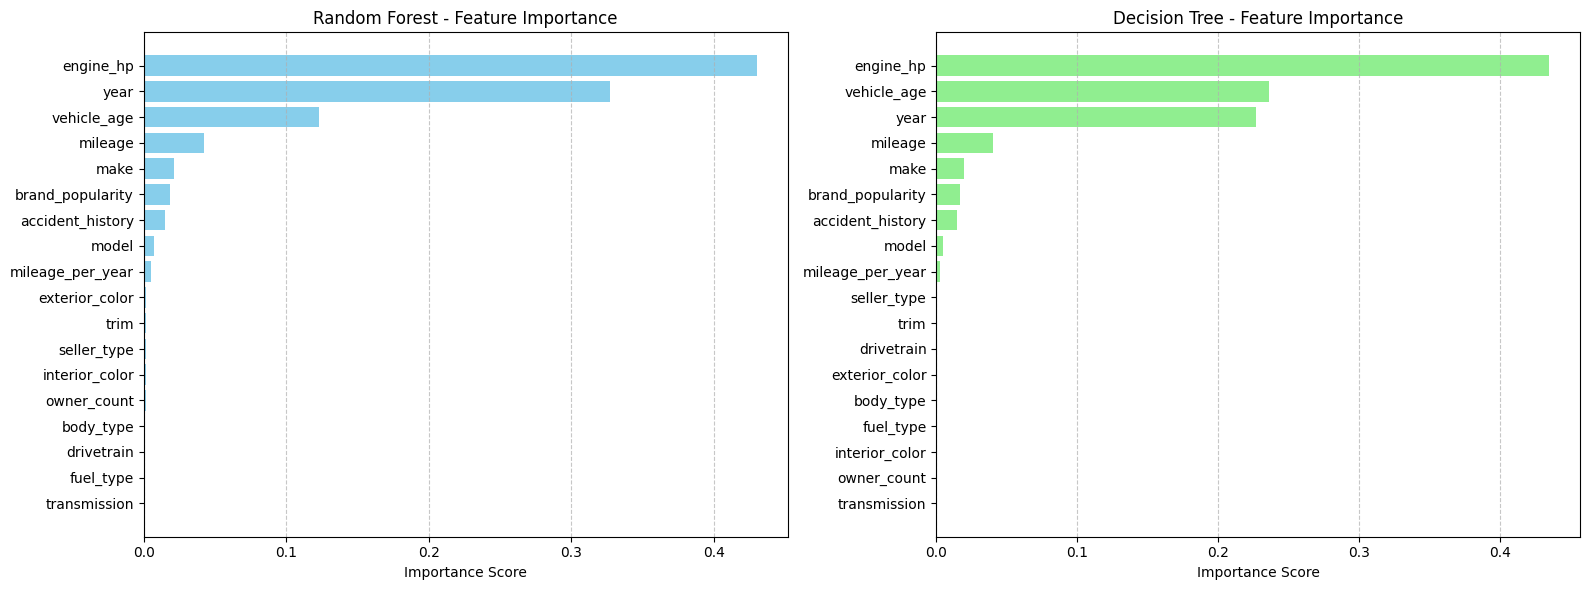

--- Failure Analysis ---
Vehicle Index with Worst Prediction: 877998
Actual Price: $93,422.09
Predicted Price: $49,499.57
Absolute Error: $43,922.52

Vehicle Features (Encoded):
make                  18.00000
model                 68.00000
year                2025.00000
mileage              500.00000
engine_hp            434.00000
transmission           0.00000
fuel_type              0.00000
drivetrain             2.00000
body_type              4.00000
exterior_color         2.00000
interior_color         0.00000
owner_count            1.00000
accident_history      -1.00000
seller_type            0.00000
trim                   3.00000
vehicle_age            1.00000
mileage_per_year     500.00000
brand_popularity       0.04021
dtype: float64


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 0. Prepare Test Data ---
# Extract X_test and y_test for the price regression from your test_df
drop_cols = ['price', 'condition']
features = test_df.drop(columns=drop_cols).columns.tolist()

X_test = test_df[features].values.astype(float)
y_test_price = test_df['price'].values.astype(float)

# Extract the best trained regressor models from Section D
best_rf_reg = grid_rf_reg.best_estimator_
best_dt_reg = grid_dt_reg.best_estimator_

# --- 1. Feature Importance Extraction ---
rf_importances = best_rf_reg.feature_importances_
dt_importances = best_dt_reg.feature_importances_

# Create a DataFrame to easily sort and plot the importances
importance_df = pd.DataFrame({
    'Feature': features,
    'RF_Importance': rf_importances,
    'DT_Importance': dt_importances
})

# Sort by Random Forest importance
importance_df_rf = importance_df.sort_values(by='RF_Importance', ascending=True)
# Sort by Decision Tree importance
importance_df_dt = importance_df.sort_values(by='DT_Importance', ascending=True)

# --- 2. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Random Forest Importances
axes[0].barh(importance_df_rf['Feature'], importance_df_rf['RF_Importance'], color='skyblue')
axes[0].set_title('Random Forest - Feature Importance')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Plot Decision Tree Importances
axes[1].barh(importance_df_dt['Feature'], importance_df_dt['DT_Importance'], color='lightgreen')
axes[1].set_title('Decision Tree - Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 3. Failure Analysis ---
print("--- Failure Analysis ---")

# Predict prices on the unseen Test Set using Random Forest
y_pred_test_rf = best_rf_reg.predict(X_test)

# Calculate the absolute errors
errors = np.abs(y_test_price - y_pred_test_rf)

# Find the index of the worst prediction (maximum error)
worst_idx = np.argmax(errors)
worst_error = errors[worst_idx]
actual_price = y_test_price[worst_idx]
predicted_price = y_pred_test_rf[worst_idx]

print(f"Vehicle Index with Worst Prediction: {test_df.index[worst_idx]}")
print(f"Actual Price: ${actual_price:,.2f}")
print(f"Predicted Price: ${predicted_price:,.2f}")
print(f"Absolute Error: ${worst_error:,.2f}")

print("\nVehicle Features (Encoded):")
worst_vehicle_features = pd.Series(X_test[worst_idx], index=features)
print(worst_vehicle_features)

##### ***↑random forest - feature importance + decision tree - feature importance↑***

##### explnation
both models had the same top 3 strongest prediactors, but theyve gotten diffrent weights.
the decision tree is more greedy compared to the random forest, and relies almost exclusively on its top 2 predicatros.
on the other hand, the ransom forest builds mulipule trees using random subsets of the features, forcing it to sometimes 'ignore' some features such as the HP or year, which means it gives other features to weigh in the decision.

## Section F 

#### F - p1. Classification Metric

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Make sure all previous cells are run so test_df is in memory and encoded!
X_test_cond = test_df.drop(columns=['price', 'condition']).values[:10000]
y_test_cond = test_df['condition'].values[:10000]

# 1. Get predictions from your Sklearn Classifier
sk_preds_cond = grid_rf_clf.predict(X_test_cond)

print("Length of y_test_cond:", len(y_test_cond))
print("Length of sk_preds_cond:", len(sk_preds_cond))

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test_cond, sk_preds_cond)

# 3. Calculate Sensitivity and Specificity per class, then average them
sensitivities = []
specificities = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)
    
    # Avoid division by zero
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    sensitivities.append(sensitivity)
    specificities.append(specificity)

print(f"Average Sensitivity (True Positive Rate): {np.mean(sensitivities):.4f}")
print(f"Average Specificity (True Negative Rate): {np.mean(specificities):.4f}")

Length of y_test_cond: 10000
Length of sk_preds_cond: 10000
Average Sensitivity (True Positive Rate): 0.3330
Average Specificity (True Negative Rate): 0.6664


##### explnation
there is a noticeable diffrence between the scores, specifity being higher than sensitivity, since there are much more cars in good-excellent condition in market than the others, and so the model is more bias towards those two conditions, which means it would be much better at predicting their prices rahter than the rare 'salvadged' or ' poor' conditions.

##### improvement methods
we could either generate more cars of those poor coditions to balance out our dataset so theres no longer a bias, or we could treat them completely separatly than our good condision ones.

#### F - p2. Random Forest Regression Test 

wev'e seen that the median had a better MSE result than the Mean ones in our random forest regression.
as explained before this happens because mathmathically the model using the mean is much more sensetive to outliers.

#### F - p3. Algorithmic Optimization

In [21]:
#A part 3
#Random Forest Wrapper
class RandomForest:
    def __init__(self, n_trees=10, task='classification', min_samples_leaf=5, max_depth=100):
        self.n_trees = n_trees
        self.task = task
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y, feature_names=None):
        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(
                task=self.task, 
                min_samples_leaf=self.min_samples_leaf, 
                max_depth=self.max_depth
            )
            # Bootstrap sampling: random rows with replacement
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            
            tree.fit(X[idxs], y[idxs], feature_names)
            self.trees.append(tree)

    def _best_split(self, X, y):
        best_gain = -float('inf')
        split_idx, split_threshold = None, None
        
        # OPTIMIZATION: Instead of checking every unique value, we use 20 Histogram Bins
        n_bins = 20 

        for feat_idx in range(X.shape[1]):
            X_column = X[:, feat_idx]
            
            # Create discrete intervals (bins) using percentiles
            thresholds = np.unique(np.percentile(X_column, np.linspace(0, 100, n_bins)))
            
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)

                # CONSTRAINT 2: min_samples_leaf
                if len(left_idxs) < self.min_samples_leaf or len(right_idxs) < self.min_samples_leaf:
                    continue

                if self.task == 'classification':
                    gain = self._gini_gain(y, y[left_idxs], y[right_idxs])
                else:
                    gain = self._ssr_reduction(y, y[left_idxs], y[right_idxs])

                # CONSTRAINT 1: Alphabetical Tie-Breaker
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr
                elif gain == best_gain and split_idx is not None:
                    current_name = self.feature_names[feat_idx]
                    best_name = self.feature_names[split_idx]
                    if current_name < best_name:
                        split_idx = feat_idx
                        split_threshold = thr

        return split_idx, split_threshold

##### explanation
##### runtime
the histogram based split improved our run time by a lot, [how much did the first take and how much did the second one take], we assume this occurs since the algorither evaluates 20 threshhold splits per feature instead of the thougnands of unique values

##### precision
the presicion is indeed lower though not by a significant amount, we even get less overfitting.